# Our Baseline Model
## Flat EEG  (Text + Image + Flat EEG)

- Gates conditioned on Text embedding only.
- 5 folds for Leave-Meme-Out
- 5 Folds for Leave-Subject-Out (Ablation), lighter config its a diagnostic not the headling result.

In [2]:
#Libraries
import os
import copy
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, roc_auc_score
from transformers import AutoTokenizer, AutoModel, AlignProcessor, AlignModel, get_linear_schedule_with_warmup
warnings.filterwarnings('ignore')

#CUDA version
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

#Path
#Google Colab or not
try:
    import google.colab
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    path = "/content/drive/MyDrive/multimodal-exist"
    os.chdir(path)
    print(f"Loading data from Google Drive: {path}")
    print(f"\nDocuments in {path}:\n")
    for item in os.listdir():
        print(item)    
else:
    path="C:/Users/diego/Desktop/multimodal-eeg-spatial-gates"
    os.chdir(path)
    print(f"Loading data locally from: {path}")

#Test Mode
TEST = False
print(f"TEST MODE: {TEST}")

PyTorch: 2.11.0+cu128
CUDA: True
Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data from Google Drive: /content/drive/MyDrive/multimodal-exist

Documents in /content/drive/MyDrive/multimodal-exist:

data
notebooks
results
inference
TEST MODE: False


In [3]:
#Paths
DATA_PATH  = "data/processed/train_base_subjects.parquet"
IMG_PATH   = "data/memes/train/memes/"   
OUTPUT_DIR = "results/m1_flat_eeg_baseline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
#Encoders
TEXT_MODEL_NAME  = "microsoft/mdeberta-v3-base"
ALIGN_MODEL_NAME = "kakaobrain/align-base"

#Vision layers to unfreeze
VISION_UNFREEZE_BLOCKS = 3   # last N blocks of ALIGN vision encoder to unfreeze

#CONFIG
MAX_TEXT_LENGTH = 256
COMMON_DIM = 768
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 1e-2
WARMUP_RATIO = 0.1
GATE_TEMPERATURE = 0.3
SEED = 42

# Leave-Meme-Out (Our main protocol)
LMO_N_FOLDS = 5
LMO_NUM_EPOCHS = 20
LMO_PATIENCE = 5


# Leave-Subject-Out (Our proposed ablation)
LSO_NUM_EPOCHS = 10
LSO_PATIENCE = 3

#If Test mode, we reduce epochs, folds, patience and batch size for both protocols.
if TEST:
    LMO_N_FOLDS = 2
    LMO_NUM_EPOCHS = 2
    LMO_PATIENCE = 1
    LSO_NUM_EPOCHS = 2
    LSO_PATIENCE = 1
    BATCH_SIZE = 8

#Loss weights for the 3 tasks (sum to 1.0)
LOSS_W21 = 0.40  # Task 2.1: Sexism Detection
LOSS_W22 = 0.35  # Task 2.2: Directness Classification
LOSS_W23 = 0.25  # Task 2.3: Sexism Category Classification (multi-label)

#Label columns
TASK21_COL = "sexist_hard"
TASK22_COL= "direct_hard"
TASK23_COLS = [
    "cat_hard_ideological_inequality",
    "cat_hard_stereotyping_dominance",
    "cat_hard_objectification",
    "cat_hard_sexual_violence",
    "cat_hard_misogyny_nsv",]


#Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Text encoder: {TEXT_MODEL_NAME}")
print(f"Vision encoder: {ALIGN_MODEL_NAME} (unfreeze last {VISION_UNFREEZE_BLOCKS} blocks)")
print(f"Device: {DEVICE}")
print(f"Leave-Meme-Out: {LMO_N_FOLDS} folds | {LMO_NUM_EPOCHS} epochs | patience {LMO_PATIENCE}")
print(f"Leave-Subject-Out: {LSO_NUM_EPOCHS} epochs | patience {LSO_PATIENCE}  (ablation -- lighter protocol)")

#Set seed for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f"Seed set: {SEED}")

Text encoder: microsoft/mdeberta-v3-base
Vision encoder: kakaobrain/align-base (unfreeze last 3 blocks)
Device: cuda
Leave-Meme-Out: 5 folds | 20 epochs | patience 5
Leave-Subject-Out: 10 epochs | patience 3  (ablation -- lighter protocol)
Seed set: 42


## Read Data

In [5]:
df = pd.read_parquet(DATA_PATH)

BANDS = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
EEG_COLS = [f"EXG_Channel_{ch}_{band}_power" for ch in range(16) for band in BANDS]
EEG_DIM = len(EEG_COLS)

print(f"Dataset shape: {df.shape}")
print(f"EEG features: {EEG_DIM}  (flat, no spatial engineering)")
df.head(3)

Dataset shape: (8090, 104)
EEG features: 80  (flat, no spatial engineering)


,meme_id,subject_id,lang,text,image_file,split,n_eeg_subjects,EXG_Channel_0_Delta_power,EXG_Channel_0_Theta_power,EXG_Channel_0_Alpha_power,...,cat_hard_stereotyping_dominance,cat_hard_objectification,cat_hard_sexual_violence,cat_hard_misogyny_nsv,cat_soft_ideological_inequality,cat_soft_stereotyping_dominance,cat_soft_objectification,cat_soft_sexual_violence,cat_soft_misogyny_nsv,categories_valid
0,110887,ES1,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,2,-0.5379,-0.6630,-0.6211,...,0.0,1.0,0.0,0.0,0.166667,0.166667,0.666667,0.000000,0.500000,True
1,110887,ES3,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,2,-0.3520,-0.3575,-0.0700,...,0.0,1.0,0.0,0.0,0.166667,0.166667,0.666667,0.000000,0.500000,True
2,110466,ES1,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,2,0.4666,0.0987,0.7818,...,0.0,0.0,0.0,0.0,0.166667,0.500000,0.166667,0.333333,0.166667,False


In [6]:
#We filter subjects based on a threshold of 500 samples (Enough data for each subject to have a meaningful dataset)
WELL_REP_THRESHOLD = 500
subj_counts = df["subject_id"].value_counts()
WELL_REPRESENTED = sorted(subj_counts[subj_counts >= WELL_REP_THRESHOLD].index.tolist())
MARGINAL = sorted(subj_counts[subj_counts < WELL_REP_THRESHOLD].index.tolist())

if TEST:
    WELL_REPRESENTED = WELL_REPRESENTED[:3]
    print("TEST MODE: Using only the first 3 well-represented subjects for Leave-Subject-Out ablation.")

print(f"Well-represented (n={len(WELL_REPRESENTED)}): {WELL_REPRESENTED}")
print(f"Marginal (always train-only, n={len(MARGINAL)}): {MARGINAL}")

Well-represented (n=8): ['EN1', 'EN3', 'EN5', 'EN6', 'ES1', 'ES3', 'ES4', 'ES5']
Marginal (always train-only, n=4): ['EN2', 'EN7', 'ES2', 'ES8']


### We define our two Data Splits:



- **leave_meme_out_splits** (Main CV): StratifiedGroupKFold, grouped by meme_id. (No meme ever appears in both train/val) and stratified by sexist_hard (class balance preserved per fold).

- **leave_subject_out_splits**(ablation): Each fold excludes ONE well-represented subject entirely. Our marginal subjects always stay in train.

In [7]:
#Leave meme out splits generator
def leave_meme_out_splits(dframe, label_col="sexist_hard", group_col="meme_id",
                          n_folds=LMO_N_FOLDS, seed=SEED):
    
    sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    X_dummy = np.zeros(len(dframe))
    groups = dframe[group_col].to_numpy()
    labels = dframe[label_col].to_numpy()
    for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_dummy, labels, groups=groups)):
        yield fold, train_idx, val_idx

In [8]:
#We check to ensure zero meme leakage and zero subject leakage
print("Leave-Meme-Out sanity check:")
for fold, tr_idx, val_idx in leave_meme_out_splits(df):
    overlap = set(df.iloc[tr_idx]["meme_id"]) & set(df.iloc[val_idx]["meme_id"])
    print(f"Fold {fold}: train={len(tr_idx)} val={len(val_idx)} meme_overlap={len(overlap)}")


Leave-Meme-Out sanity check:
Fold 0: train=6479 val=1611 meme_overlap=0
Fold 1: train=6476 val=1614 meme_overlap=0
Fold 2: train=6467 val=1623 meme_overlap=0
Fold 3: train=6470 val=1620 meme_overlap=0
Fold 4: train=6468 val=1622 meme_overlap=0


In [9]:
def leave_subject_out_splits(dframe, eligible_subjects, subject_col="subject_id", group_col="meme_id"):
    """
    STRICT double holdout. Excludes from train not only the held-out subject's
    OWN rows, but ALSO any other subject's row for a meme the held-out subject
    saw. Without this second exclusion, ~100% of the held-out subject's memes
    remain in train via other subjects (same-language subjects largely share
    the same meme pool) -- producing inflated, memorization-driven F1 that has
    nothing to do with genuine generalization to a new individual. Confirmed
    empirically on M1: this was the cause of LSO F1=0.97 vs LMO F1=0.63 on
    Task 2.1 for the exact same architecture.
    """
    idx_array = np.arange(len(dframe))
    subj_arr  = dframe[subject_col].to_numpy()
    meme_arr  = dframe[group_col].to_numpy()
    for held_out in eligible_subjects:
        is_held_out = subj_arr == held_out
        held_out_memes = set(meme_arr[is_held_out])
        val_idx = idx_array[is_held_out]
        train_mask = (~is_held_out) & (~np.isin(meme_arr, list(held_out_memes)))
        train_idx = idx_array[train_mask]
        yield held_out, train_idx, val_idx
        

In [10]:
print("Leave-Subject-Out sanity check:")
for held_out, tr_idx, val_idx in leave_subject_out_splits(df, WELL_REPRESENTED):
    subj_leak = held_out in set(df.iloc[tr_idx]["subject_id"])
    meme_overlap = set(df.iloc[tr_idx]["meme_id"]) & set(df.iloc[val_idx]["meme_id"])
    print(f"Held out {held_out}: train={len(tr_idx):>5} val={len(val_idx):>5} "
          f"subject_leak={subj_leak} meme_overlap={len(meme_overlap)}")

Leave-Subject-Out sanity check:
Held out EN1: train= 5989 val= 1031 subject_leak=False meme_overlap=0
Held out EN3: train= 6438 val=  826 subject_leak=False meme_overlap=0
Held out EN5: train= 6000 val= 1027 subject_leak=False meme_overlap=0
Held out EN6: train= 5956 val= 1052 subject_leak=False meme_overlap=0
Held out ES1: train= 5878 val= 1075 subject_leak=False meme_overlap=0
Held out ES3: train= 6001 val= 1015 subject_leak=False meme_overlap=0
Held out ES4: train= 6450 val=  820 subject_leak=False meme_overlap=0
Held out ES5: train= 5974 val= 1025 subject_leak=False meme_overlap=0


## Dataset Class

In [11]:
class Multimodal_Dataset(Dataset):
    """
    Text + Image + Flat EEG (80-dim)
    """
    def __init__(self, df, img_dir, tokenizer, image_processor, eeg_cols, max_length=256):

        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.tokenizer = tokenizer
        self.image_processor = image_processor
        self.eeg_cols = eeg_cols
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Text
        text_enc = self.tokenizer(str(row["text"]), 
                                  max_length=self.max_length,
                                   padding="max_length", 
                                   truncation=True,
                                     return_tensors="pt")

        # Image
        img_path = os.path.join(self.img_dir, str(row["image_file"]))
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            print("Image loading failed for:", img_path)
            image = Image.new("RGB", (224, 224), color=(128, 128, 128))
        img_enc = self.image_processor(images=image, return_tensors="pt")

        # EEG Flat Vector (80-dim)
        eeg = torch.tensor(row[self.eeg_cols].values.astype(np.float32), dtype=torch.float32)

        # Task 2.1 (SEXISM)
        t21 = int(row[TASK21_COL])

        # Task 2.2 (DIRECT/JUDGEMENTAL) -- masked (non-sexist meme)
        t22_val = row[TASK22_COL]
        t22 = int(t22_val) if pd.notna(t22_val) else -1

        # Task 2.3 (multilabel categories) -- masked (non-sexist meme)
        if t21 == 1:
            t23 = torch.tensor([float(row[c]) if pd.notna(row[c]) else 0.0 for c in TASK23_COLS],
                                dtype=torch.float32)
        else:
            t23 = torch.full((len(TASK23_COLS),), -1.0)

        return {
            "input_ids": text_enc["input_ids"].squeeze(0),
            "attention_mask": text_enc["attention_mask"].squeeze(0),
            "pixel_values": img_enc["pixel_values"].squeeze(0),
            "eeg": eeg,
            "task21": torch.tensor(t21, dtype=torch.long),
            "task22": torch.tensor(t22, dtype=torch.long),
            "task23": t23,
        }


def collate_fn(batch):
    return {
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
        "eeg": torch.stack([b["eeg"] for b in batch]),
        "task21": torch.stack([b["task21"] for b in batch]),
        "task22": torch.stack([b["task22"] for b in batch]),
        "task23": torch.stack([b["task23"] for b in batch]),
    }

## Model Architecture

`z = text_emb + β·vision_emb + α·eeg_emb` 

In [12]:
#First we define a simple MLP to project our EEG vector to the common_dim (768)
class PhysioMLP(nn.Module):
    def __init__(self, input_dim, common_dim, dropout=0.2):
        super().__init__()
        hidden = common_dim // 2
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, common_dim),
            nn.LayerNorm(common_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class GatedFusionModel(nn.Module):
    """
    Gated Fusion baseline: Text + Image + Flat EEG 
    z = text_emb + beta * vision_emb + alpha * eeg_emb
    """
    def __init__(
        self,
        text_model_name=TEXT_MODEL_NAME,
        vision_model_name=ALIGN_MODEL_NAME,
        eeg_dim=80,
        num_cat=5,
        common_dim=768,
        dropout=0.1,
    ):
        super().__init__()
        self.common_dim = common_dim

        # Text encoder: mDeBERTa v3 base (768-dim [CLS] token)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_dim = self.text_encoder.config.hidden_size
        self.text_projection = nn.Linear(text_dim, common_dim) if text_dim != common_dim else nn.Identity()

        # Vision encoder (ALIGN)
        align_full = AlignModel.from_pretrained(vision_model_name)
        self.vision_encoder = align_full.vision_model
        vision_dim = align_full.config.vision_config.hidden_dim
        self.vision_projection = nn.Linear(vision_dim, common_dim) if vision_dim != common_dim else nn.Identity()

        # EEG encoder (80 dim -flat vector)
        self.eeg_encoder = PhysioMLP(eeg_dim, common_dim, dropout)

        # Gates conditioned on text embedding
        self.gate_vision = nn.Linear(common_dim, 1)  # β: how much to trust Image given this text
        self.gate_eeg = nn.Linear(common_dim, 1)  # α: how much to trust EEG given this text

        self.fusion_layer = nn.Sequential(
            nn.Linear(common_dim, common_dim),
            nn.LayerNorm(common_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Task heads
        self.head_21 = nn.Sequential(
            nn.Linear(common_dim, common_dim // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 2, 2))

        self.head_22 = nn.Sequential(
            nn.Linear(common_dim, common_dim // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 2, common_dim // 4),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 4, 2))

        self.head_23 = nn.Sequential(
            nn.Linear(common_dim, common_dim // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 2, common_dim // 4),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(common_dim // 4, num_cat))

    def encode(self, input_ids, attention_mask, pixel_values, eeg):
        
        # Text
        text_emb = self.text_projection(self.text_encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]) # (B, 768)

        # Vision
        vision_emb = self.vision_projection(self.vision_encoder(pixel_values=pixel_values).pooler_output) # (B, 768)

        # EEG
        eeg_emb = self.eeg_encoder(eeg.float()) # (B, 768)

        # Gates
        beta  = torch.sigmoid(self.gate_vision(text_emb)/GATE_TEMPERATURE) # β (B, 768)
        alpha = torch.sigmoid(self.gate_eeg(text_emb)/GATE_TEMPERATURE) # α (B, 768)

        # Gated fusion:
        z = text_emb + beta * vision_emb + alpha * eeg_emb

        #Fusion refinement and shared layer
        fused = self.fusion_layer(z)
        
        # WE return the mean of each gate across the batch for analysis
        gate_vals = {"beta": beta.mean().item(), "alpha": alpha.mean().item()}
        return fused, gate_vals

    def forward(self, input_ids, attention_mask, pixel_values, eeg):
        shared, gate_vals = self.encode(input_ids, attention_mask, pixel_values, eeg)
        return (
            self.head_21(shared),
            self.head_22(shared),
            self.head_23(shared),
            gate_vals,
        )

## Loss Functions

In [13]:
#We first compute the class weights for Task 2.1 and Task 2.2, to handle class imbalance

def compute_class_weights(dframe):
    # Task 2.1 Sexism 
    counts_21 = dframe[TASK21_COL].value_counts().sort_index()
    total_21  = counts_21.sum()
    w21_0 = total_21/(2 * counts_21[0])
    w21_1 = total_21/(2 * counts_21[1])
    weight_21 = torch.tensor([w21_0, w21_1], dtype=torch.float32)

    sexist_df = dframe[dframe[TASK21_COL] == 1]
    counts_22 = sexist_df[TASK22_COL].value_counts().sort_index()
    total_22  = counts_22.sum()
    w22_0 = total_22/(2 * counts_22[0])
    w22_1 = total_22/(2 * counts_22[1])
    weight_22 = torch.tensor([w22_0, w22_1], dtype=torch.float32)

    print(f"Task 2.1 weights: class 0 (non-sexist): {w21_0:.3f} | class 1 (sexist): {w21_1:.3f}")
    print(f"Task 2.2 weights: class 0 (judgemental): {w22_0:.3f} | class 1 (direct): {w22_1:.3f}")
    return weight_21, weight_22

WEIGHT_21, WEIGHT_22 = compute_class_weights(df)

Task 2.1 weights: class 0 (non-sexist): 1.461 | class 1 (sexist): 0.760
Task 2.2 weights: class 0 (judgemental): 2.137 | class 1 (direct): 0.653


In [14]:
def compute_multitask_loss(logits_21, logits_22, logits_23,
                           labels_21, labels_22, labels_23,
                           weight_21, weight_22,
                           w21=LOSS_W21, w22=LOSS_W22, w23=LOSS_W23):
    """
    - Task 2.1: CrossEntropy (all samples)
    - Task 2.2: CrossEntropy (masked: only sexist, label != -1)
    - Task 2.3: Weighted BCE per label (masked: only sexist, label != -1)
    """


    # Task 2.1
    loss_21 = F.cross_entropy(logits_21, labels_21, weight=weight_21.to(logits_21.device))

    # Task 2.2 (Direct/ Judgemental) — mask non-sexist samples
    mask_22 = labels_22 != -1
    loss_22 = (
        F.cross_entropy(logits_22[mask_22], labels_22[mask_22], weight=weight_22.to(logits_22.device))
        if mask_22.sum() > 0
        else torch.tensor(0.0, device=logits_22.device)
    )

    # Task 2.3 (Multi-label) — mask non-sexist samples (label == -1)
    mask_23 = (labels_23 != -1).any(dim=1)
    if mask_23.sum() > 0:
        labels_masked = labels_23[mask_23]
        pos_weight = ((labels_masked == 0).sum(0).float() / (labels_masked == 1).sum(0).float().clamp(min=1)).to(logits_23.device)
        pos_weight = pos_weight.clamp(max=5.0)
        loss_23 = F.binary_cross_entropy_with_logits(logits_23[mask_23], labels_masked, pos_weight=pos_weight)
    else:
        loss_23 = torch.tensor(0.0, device=logits_23.device)

    total = w21 * loss_21 + w22 * loss_22 + w23 * loss_23
    return total, loss_21.item(), loss_22.item(), loss_23.item()

## Training & Evaluation Functions

In [15]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    l21_acc = l22_acc = l23_acc = 0.0
    beta_acc = alpha_acc = 0.0

    for batch in tqdm(loader, desc="  train", leave=False):
        optimizer.zero_grad()
        with autocast(dtype=torch.bfloat16):
            logits_21, logits_22, logits_23, gate_vals = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["pixel_values"].to(device),
                batch["eeg"].to(device),
            )

            loss, l21, l22, l23 = compute_multitask_loss(
                logits_21, logits_22, logits_23,
                batch["task21"].to(device),
                batch["task22"].to(device),
                batch["task23"].to(device),
                WEIGHT_21, WEIGHT_22)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        l21_acc += l21; l22_acc += l22; l23_acc += l23
        beta_acc += gate_vals["beta"]
        alpha_acc += gate_vals["alpha"]

    n = len(loader)
    return {
        "total": total_loss/n,
        "l21": l21_acc/n, 
        "l22": l22_acc/n, 
        "l23": l23_acc/n,
        "beta": beta_acc/n,    # mean gate for Image
        "alpha": alpha_acc/n,  # mean gate for EEG
    }


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    all_21_preds, all_21_probs, all_21_labels = [], [], []
    all_22_preds, all_22_probs, all_22_labels = [], [], []
    all_23_preds, all_23_probs, all_23_labels = [], [], []
    beta_acc = alpha_acc = 0.0

    for batch in tqdm(loader, desc="  eval", leave=False):
        with autocast(dtype=torch.bfloat16):
            logits_21, logits_22, logits_23, gate_vals = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["pixel_values"].to(device),
                batch["eeg"].to(device))

        logits_21 = logits_21.float()
        logits_22 = logits_22.float()
        logits_23 = logits_23.float()

        # Task 2.1
        prob_21 = F.softmax(logits_21, dim=1)[:, 1].cpu().numpy()
        pred_21 = logits_21.argmax(dim=1).cpu().numpy()
        all_21_preds.extend(pred_21); all_21_probs.extend(prob_21); all_21_labels.extend(batch["task21"].numpy())

        # Task 2.2 -- only sexist
        mask_22 = batch["task22"] != -1
        if mask_22.sum() > 0:
            prob_22 = F.softmax(logits_22[mask_22], dim=1)[:, 1].cpu().numpy()
            pred_22 = logits_22[mask_22].argmax(dim=1).cpu().numpy()
            all_22_preds.extend(pred_22); all_22_probs.extend(prob_22)
            all_22_labels.extend(batch["task22"][mask_22].numpy())

        # Task 2.3 -- only sexist
        mask_23 = (batch["task23"] != -1).any(dim=1)
        if mask_23.sum() > 0:
            prob_23 = torch.sigmoid(logits_23[mask_23]).cpu().numpy()
            pred_23 = (prob_23 >= 0.5).astype(int)
            all_23_probs.extend(prob_23); all_23_preds.extend(pred_23)
            all_23_labels.extend(batch["task23"][mask_23].numpy())

        beta_acc  += gate_vals["beta"]
        alpha_acc += gate_vals["alpha"]

    n = len(loader)
    metrics = {}

    # Task 2.1
    metrics["f1_21"] = f1_score(all_21_labels, all_21_preds, average="macro", zero_division=0)
    probs_21_arr = np.array(all_21_probs)
    metrics["auc_21"] = (roc_auc_score(all_21_labels, probs_21_arr) if not np.isnan(probs_21_arr).any() else 0.0)

    # Task 2.2
    if all_22_labels:
        probs_22_arr = np.array(all_22_probs)
        metrics["f1_22"] = f1_score(all_22_labels, all_22_preds, average="macro", zero_division=0)
        metrics["auc_22"] = (
            roc_auc_score(all_22_labels, probs_22_arr)
            if not np.isnan(probs_22_arr).any() and len(set(all_22_labels)) > 1
            else 0.5
        )
    else:
        metrics["f1_22"] = metrics["auc_22"] = 0.0

    # Task 2.3
    if all_23_labels:
        labels_23_arr = np.array(all_23_labels)
        probs_23_arr  = np.array(all_23_probs)
        preds_23_arr  = np.array(all_23_preds)
        metrics["f1_23"] = f1_score(labels_23_arr, preds_23_arr, average="macro", zero_division=0)
        aucs = [
            roc_auc_score(labels_23_arr[:, i], probs_23_arr[:, i])
            for i in range(labels_23_arr.shape[1])
            if len(set(labels_23_arr[:, i])) > 1 and not np.isnan(probs_23_arr[:, i]).any()
        ]
        metrics["auc_23"] = np.mean(aucs) if aucs else 0.5
    else:
        metrics["f1_23"] = metrics["auc_23"] = 0.0

    metrics["beta"]  = beta_acc / n
    metrics["alpha"] = alpha_acc / n
    return metrics

## Initialize Tokenizer & Processor

In [16]:
print("Loading tokenizer and processors...")
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
align_processor = AlignProcessor.from_pretrained(ALIGN_MODEL_NAME)

print(f"Tokenizer: {TEXT_MODEL_NAME}")
print(f"Processor: {ALIGN_MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

Loading tokenizer and processors...


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.25k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/399 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizer: microsoft/mdeberta-v3-base
Processor: kakaobrain/align-base
Vocab size: 250101


## We create a shared Fold-Runner

One function that is ised by both LMO and LSO. This guaranteees the 2 CV schemes used identicial model/training code. So any performance gap between them is for the validation scheme.

In [17]:
def run_fold(df_tr, df_val, run_tag, num_epochs, patience, seed_offset=0):
    
    set_seed(SEED + seed_offset)

    train_ds = Multimodal_Dataset(df_tr,  IMG_PATH, tokenizer, align_processor, EEG_COLS, MAX_TEXT_LENGTH)
    val_ds   = Multimodal_Dataset(df_val, IMG_PATH, tokenizer, align_processor, EEG_COLS, MAX_TEXT_LENGTH)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,collate_fn=collate_fn, num_workers=4, persistent_workers=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,collate_fn=collate_fn, num_workers=4, persistent_workers=True)

    model = GatedFusionModel(eeg_dim=EEG_DIM, common_dim=COMMON_DIM).to(DEVICE).float()

    #We freeze all vision and text encoders in test mode.
    if TEST:
        for p in model.text_encoder.parameters():
            p.requires_grad = False
        for p in model.vision_encoder.parameters():
            p.requires_grad = False
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        print("Encoders: fully frozen (TEST mode)")

    # If not test model, we unfreeze both text and vision encoders.
    else:
        for p in model.vision_encoder.parameters():
            p.requires_grad = False
        all_blocks = list(model.vision_encoder.encoder.blocks.children())
        for block in all_blocks[-VISION_UNFREEZE_BLOCKS:]:
            for p in block.parameters():
                p.requires_grad = True

        for p in model.text_encoder.parameters():
            p.requires_grad = True

        vision_unfrozen_params = [p for p in model.vision_encoder.parameters() if p.requires_grad]
        other_params = [p for p in model.parameters() if p.requires_grad and not any(p is vp for vp in vision_unfrozen_params)]

        optimizer = torch.optim.AdamW([
            {"params": other_params, "lr": LEARNING_RATE},
            {"params": vision_unfrozen_params, "lr": LEARNING_RATE * 0.1},
        ], weight_decay=WEIGHT_DECAY)

    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    best_val_f1 = 0.0
    patience_cnt = 0
    best_state = copy.deepcopy(model.state_dict())
    history = []

    for epoch in range(num_epochs):
        train_losses = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        val_metrics  = evaluate(model, val_loader, DEVICE)

        val_f1 = (val_metrics["f1_21"] * LOSS_W21 +
                  val_metrics["f1_22"] * LOSS_W22 +
                  val_metrics["f1_23"] * LOSS_W23)

        history.append({
            "epoch": epoch + 1,
            "loss": train_losses["total"],
            "l21": train_losses["l21"], "l22": train_losses["l22"], "l23": train_losses["l23"],
            "train_beta": train_losses["beta"], "train_alpha": train_losses["alpha"],
            "f1_21": val_metrics["f1_21"], "auc_21": val_metrics["auc_21"],
            "f1_22": val_metrics["f1_22"], "auc_22": val_metrics["auc_22"],
            "f1_23": val_metrics["f1_23"], "auc_23": val_metrics["auc_23"],
            "val_beta": val_metrics["beta"], "val_alpha": val_metrics["alpha"],
        })

        print(
            f"  [{run_tag}] Ep {epoch+1:02d}/{num_epochs} | "
            f"Loss: {train_losses['total']:.4f} "
            f"(21:{train_losses['l21']:.3f} 22:{train_losses['l22']:.3f} 23:{train_losses['l23']:.3f}) | "
            f"Val F1: 21={val_metrics['f1_21']:.4f} 22={val_metrics['f1_22']:.4f} 23={val_metrics['f1_23']:.4f} | "
            f"Gates β={val_metrics['beta']:.3f} α={val_metrics['alpha']:.3f}",
            end=""
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_cnt = 0
            best_state = copy.deepcopy(model.state_dict())
            ckpt_path = os.path.join(OUTPUT_DIR, f"{run_tag}_best.pt")
            torch.save(best_state, ckpt_path)
            print(" Ok!")
        else:
            patience_cnt += 1
            print(f" (patience {patience_cnt}/{patience})")
            if patience_cnt >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    final_metrics = evaluate(model, val_loader, DEVICE)

    del model
    torch.cuda.empty_cache()

    return final_metrics, pd.DataFrame(history)

## 1. Leave-Meme-Out

Full protocoal (5 folds, 20 epochs, patience 5)

In [ ]:
lmo_results = []
lmo_histories = {}

print("=" * 70)
print(f"LEAVE-MEME-OUT ({LMO_N_FOLDS} folds)")
print("=" * 70)

for fold_idx, train_idx, val_idx in leave_meme_out_splits(df, n_folds=LMO_N_FOLDS):
    print(f"\n{'-'*70}\nFOLD {fold_idx+1}/{LMO_N_FOLDS}\n{'-'*70}")

    df_tr  = df.iloc[train_idx].reset_index(drop=True)
    df_val = df.iloc[val_idx].reset_index(drop=True)

    final_metrics, history = run_fold(
        df_tr, df_val,
        run_tag=f"lmo_fold{fold_idx+1}",
        num_epochs=LMO_NUM_EPOCHS, patience=LMO_PATIENCE,
        seed_offset=fold_idx,
    )

    lmo_results.append({
        "fold": fold_idx + 1,
        "f1_21": final_metrics["f1_21"], "auc_21": final_metrics["auc_21"],
        "f1_22": final_metrics["f1_22"], "auc_22": final_metrics["auc_22"],
        "f1_23": final_metrics["f1_23"], "auc_23": final_metrics["auc_23"],
        "beta_image": final_metrics["beta"], "alpha_eeg": final_metrics["alpha"],
    })
    lmo_histories[fold_idx + 1] = history

    print(
        f"\n  Fold {fold_idx+1} FINAL | "
        f"F1: 21={final_metrics['f1_21']:.4f} 22={final_metrics['f1_22']:.4f} 23={final_metrics['f1_23']:.4f} | "
        f"AUC: 21={final_metrics['auc_21']:.4f} 22={final_metrics['auc_22']:.4f} 23={final_metrics['auc_23']:.4f}\n"
        f"  Gates -> beta(Image)={final_metrics['beta']:.4f}  alpha(EEG)={final_metrics['alpha']:.4f}"
    )

df_lmo_results = pd.DataFrame(lmo_results)
print("\n" + "*" * 70)
print("Leave-Meme-Out complete")
print("*" * 70)

LEAVE-MEME-OUT (5 folds)

----------------------------------------------------------------------
FOLD 1/5
----------------------------------------------------------------------


pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from di

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

...

  train:   0%|          | 0/405 [00:00<?, ?it/s]

  eval:   0%|          | 0/102 [00:00<?, ?it/s]

  [lmo_fold5] Ep 20/20 | Loss: 0.0442 (21:0.005 22:0.009 23:0.155) | Val F1: 21=0.6290 22=0.5139 23=0.1887 | Gates β=0.801 α=0.024 Ok!


  eval:   0%|          | 0/102 [00:00<?, ?it/s]


  Fold 5 FINAL | F1: 21=0.6290 22=0.5139 23=0.1887 | AUC: 21=0.6955 22=0.5586 23=0.6662
  Gates -> beta(Image)=0.8005  alpha(EEG)=0.0241

**********************************************************************
Leave-Meme-Out complete
**********************************************************************


In [ ]:
print("=" * 60)
print(f"LEAVE-MEME-OUT RESULTS -- Flat EEG Baseline ({LMO_N_FOLDS} folds)")
print("=" * 60)

for task, tname in [("21", "Sexism Detection"), ("22", "Source Intention"), ("23", "Sexism Categorization")]:
    f1  = df_lmo_results[f"f1_{task}"]
    auc = df_lmo_results[f"auc_{task}"]
    print(f"  Task 2.{task[-1]} ({tname}):")
    print(f"    Macro F1 = {f1.mean():.4f} ± {f1.std():.4f}")
    print(f"    AUC      = {auc.mean():.4f} ± {auc.std():.4f}")

print("\nGate values (mean across folds):")
print(f"  β (Image weight) = {df_lmo_results['beta_image'].mean():.4f} ± {df_lmo_results['beta_image'].std():.4f}")
print(f"  α (EEG   weight) = {df_lmo_results['alpha_eeg'].mean():.4f} ± {df_lmo_results['alpha_eeg'].std():.4f}")

df_lmo_results.to_csv(os.path.join(OUTPUT_DIR, "lmo_fold_results.csv"), index=False)

LEAVE-MEME-OUT RESULTS -- Flat EEG Baseline (5 folds)
  Task 2.1 (Sexism Detection):
    Macro F1 = 0.6335 ± 0.0082
    AUC      = 0.6780 ± 0.0145
  Task 2.2 (Source Intention):
    Macro F1 = 0.5387 ± 0.0353
    AUC      = 0.5800 ± 0.0436
  Task 2.3 (Sexism Categorization):
    Macro F1 = 0.1643 ± 0.0441
    AUC      = 0.6380 ± 0.0305

Gate values (mean across folds):
  β (Image weight) = 0.8876 ± 0.0849
  α (EEG   weight) = 0.0367 ± 0.0229


## Section B. Leave-Subject-Out (ABLATION)

Full protocol 10 epochs, patience 3. Only the well-represented subjects.

In [19]:
lso_results = []
lso_histories = {}

print("=" * 70)
print(f"LEAVE-SUBJECT-OUT ({len(WELL_REPRESENTED)} held-out subjects)")
print("=" * 70)

for held_out, train_idx, val_idx in leave_subject_out_splits(df, WELL_REPRESENTED):
    print(f"\n{'-'*70}\nHELD OUT: {held_out}\n{'-'*70}")

    df_tr  = df.iloc[train_idx].reset_index(drop=True)
    df_val = df.iloc[val_idx].reset_index(drop=True)

    final_metrics, history = run_fold(
        df_tr, df_val,
        run_tag=f"lso_{held_out}",
        num_epochs=LSO_NUM_EPOCHS, patience=LSO_PATIENCE,
        seed_offset=100,
    )

    lso_results.append({
        "held_out_subject": held_out,
        "f1_21": final_metrics["f1_21"], "auc_21": final_metrics["auc_21"],
        "f1_22": final_metrics["f1_22"], "auc_22": final_metrics["auc_22"],
        "f1_23": final_metrics["f1_23"], "auc_23": final_metrics["auc_23"],
        "beta_image": final_metrics["beta"], "alpha_eeg": final_metrics["alpha"],
    })
    lso_histories[held_out] = history

    print(
        f"\n  Held-out {held_out} FINAL | "
        f"F1: 21={final_metrics['f1_21']:.4f} 22={final_metrics['f1_22']:.4f} 23={final_metrics['f1_23']:.4f}"
    )

df_lso_results = pd.DataFrame(lso_results)
print("\n" + "*" * 70)
print("Leave-Subject-Out complete")
print("*" * 70)

LEAVE-SUBJECT-OUT (8 held-out subjects)

----------------------------------------------------------------------
HELD OUT: EN1
----------------------------------------------------------------------


pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
mask_predictions.classifier.bias           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from di

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

...

  train:   0%|          | 0/374 [00:00<?, ?it/s]

  eval:   0%|          | 0/65 [00:00<?, ?it/s]

  [lso_ES5] Ep 07/10 | Loss: 0.2821 (21:0.078 22:0.264 23:0.634) | Val F1: 21=0.6285 22=0.5316 23=0.0593 | Gates β=0.914 α=0.008 (patience 3/3)
  Early stopping at epoch 7


  eval:   0%|          | 0/65 [00:00<?, ?it/s]


  Held-out ES5 FINAL | F1: 21=0.6167 22=0.5564 23=0.0505

**********************************************************************
Leave-Subject-Out complete
**********************************************************************


In [20]:
print("=" * 60)
print(f"LEAVE-SUBJECT-OUT RESULTS -- Flat EEG Baseline ({len(WELL_REPRESENTED)} held-out subjects)")
print("=" * 60)

for task, tname in [("21", "Sexism Detection"), ("22", "Source Intention"), ("23", "Sexism Categorization")]:
    f1 = df_lso_results[f"f1_{task}"]
    print(f"  Task 2.{task[-1]} ({tname}): Macro F1 = {f1.mean():.4f} ± {f1.std():.4f}")

print("\nPer-subject F1 (Task 2.1), sorted:")
print(df_lso_results[["held_out_subject", "f1_21"]].sort_values("f1_21", ascending=False).to_string(index=False))

df_lso_results.to_csv(os.path.join(OUTPUT_DIR, "lso_subject_results.csv"), index=False)

LEAVE-SUBJECT-OUT RESULTS -- Flat EEG Baseline (8 held-out subjects)
  Task 2.1 (Sexism Detection): Macro F1 = 0.6308 ± 0.0179
  Task 2.2 (Source Intention): Macro F1 = 0.5200 ± 0.0287
  Task 2.3 (Sexism Categorization): Macro F1 = 0.0695 ± 0.0376

Per-subject F1 (Task 2.1), sorted:
held_out_subject    f1_21
             EN5 0.655132
             EN3 0.655094
             ES1 0.635174
             EN6 0.631675
             EN1 0.629785
             ES3 0.618918
             ES5 0.616699
             ES4 0.604292


## The GAP: Leave-Meme-Out vs Leave-Subject-Out 

Based on our first notebook (Methodology and EDA) a large gap suggest the models leans on subject identity, neural fingerprint rather than meme content. In contrast, a small gap suggest the model generalizes to new individuals about as well as it generalizes to new memes.

In [21]:
LMO_RESULTS_PATH  = "results/m1_flat_eeg_baseline/lmo_fold_results.csv"
df_lmo_results = pd.read_csv(LMO_RESULTS_PATH)
df_lmo_results.head(3)

,fold,f1_21,auc_21,f1_22,auc_22,f1_23,auc_23,beta_image,alpha_eeg
0,1,0.625840,0.673000,0.520725,0.531503,0.194210,0.619597,0.997525,0.021016
1,2,0.645713,0.667834,0.505201,0.559559,0.180131,0.613675,0.919245,0.015222
2,3,0.637847,0.662424,0.579168,0.637267,0.171629,0.675972,0.802619,0.062384


In [22]:
print("=" * 60)
print("LEAVE-MEME-OUT vs LEAVE-SUBJECT-OUT ")
print("=" * 60)

gap_rows = []
for task, tname in [("21", "Sexism"), ("22", "Intention"), ("23", "Categories")]:
    lmo_f1 = df_lmo_results[f"f1_{task}"].mean()
    lso_f1 = df_lso_results[f"f1_{task}"].mean()
    gap = lmo_f1 - lso_f1
    flag = "  <-- large gap, possible subject-identity reliance" if gap > 0.05 else ""
    gap_rows.append({"task": f"2.{task[-1]} ({tname})", "lmo_f1": lmo_f1, "lso_f1": lso_f1, "gap": gap})
    print(f"  Task 2.{task[-1]} ({tname}): LMO={lmo_f1:.4f}  LSO={lso_f1:.4f}  gap={gap:+.4f}{flag}")

df_gap = pd.DataFrame(gap_rows)
df_gap.to_csv(os.path.join(OUTPUT_DIR, "lmo_vs_lso_gap.csv"), index=False)

LEAVE-MEME-OUT vs LEAVE-SUBJECT-OUT 
  Task 2.1 (Sexism): LMO=0.6335  LSO=0.6308  gap=+0.0026
  Task 2.2 (Intention): LMO=0.5387  LSO=0.5200  gap=+0.0187
  Task 2.3 (Categories): LMO=0.1643  LSO=0.0695  gap=+0.0949  <-- large gap, possible subject-identity reliance


## Visualizations

NameError: name 'lmo_histories' is not defined

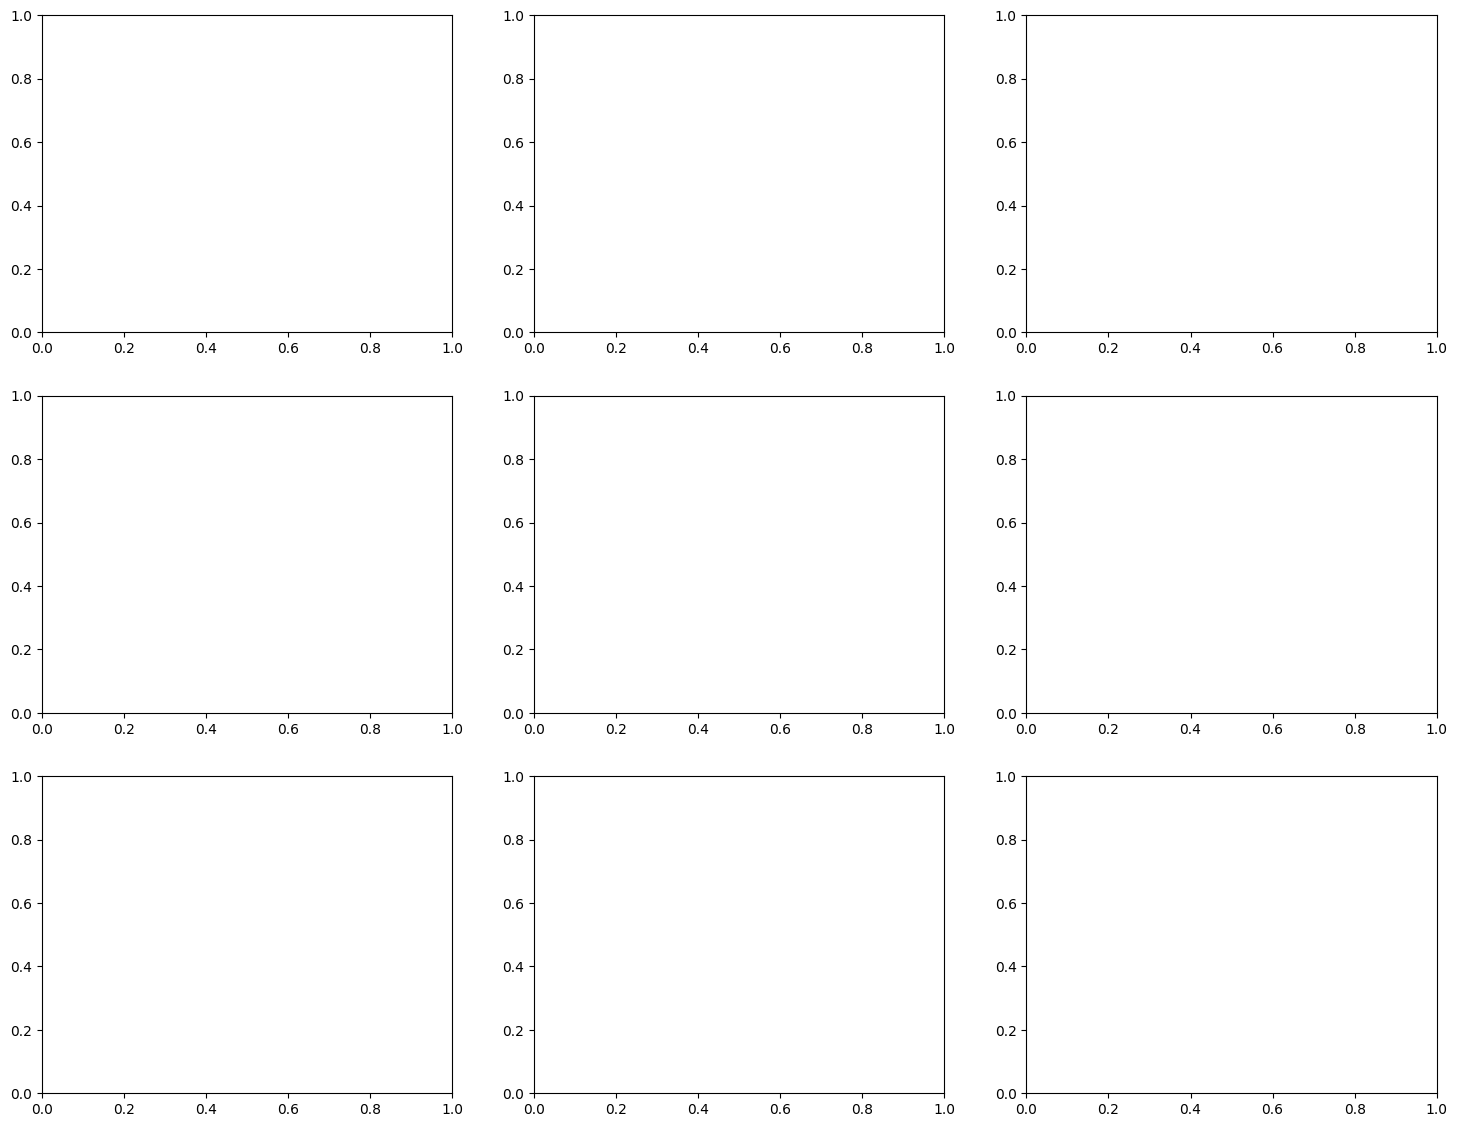

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

tasks  = ["21", "22", "23"]
labels = ["Task 2.1 — Sexism", "Task 2.2 — Intention", "Task 2.3 — Categories"]
colors = ["blue", "orange", "green"]

for col, (task, label, color) in enumerate(zip(tasks, labels, colors)):
    # Row 0: LMO training curves
    ax = axes[0, col]
    for fold_n, hist_df in lmo_histories.items():
        ax.plot(hist_df["epoch"], hist_df[f"f1_{task}"], alpha=0.7, linewidth=1.5, label=f"Fold {fold_n}")
    ax.set_title(f"{label}\nLMO Val Macro F1 per epoch", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Macro F1")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    # Row 1: LMO per-fold bar
    ax = axes[1, col]
    vals = df_lmo_results[f"f1_{task}"]
    bars = ax.bar([f"F{i}" for i in range(1, len(vals)+1)], vals, color=color, alpha=0.8)
    ax.axhline(vals.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean {vals.mean():.4f}")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f"{v:.4f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{label}\nLMO Macro F1 per fold", fontweight="bold")
    ax.set_ylim(max(0, vals.min()-0.05), min(1.0, vals.max()+0.05))
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

    # Row 2: LSO per-subject bar (ablation)
    ax = axes[2, col]
    vals_lso = df_lso_results[f"f1_{task}"]
    bars = ax.bar(df_lso_results["held_out_subject"], vals_lso, color=color, alpha=0.5)
    ax.axhline(vals_lso.mean(), color="red", linestyle="--", linewidth=1.5, label=f"LSO mean {vals_lso.mean():.4f}")
    ax.axhline(vals.mean(), color="black", linestyle=":", linewidth=1.5, label=f"LMO mean {vals.mean():.4f}")
    ax.set_title(f"{label}\nLSO Macro F1 per held-out subject", fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)

plt.suptitle("M1 — Flat EEG Baseline: Text + Image + EEG (80-dim, no ET)",
              fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "m1_results.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Plot saved in {plot_path}")

NameError: name 'lmo_histories' is not defined

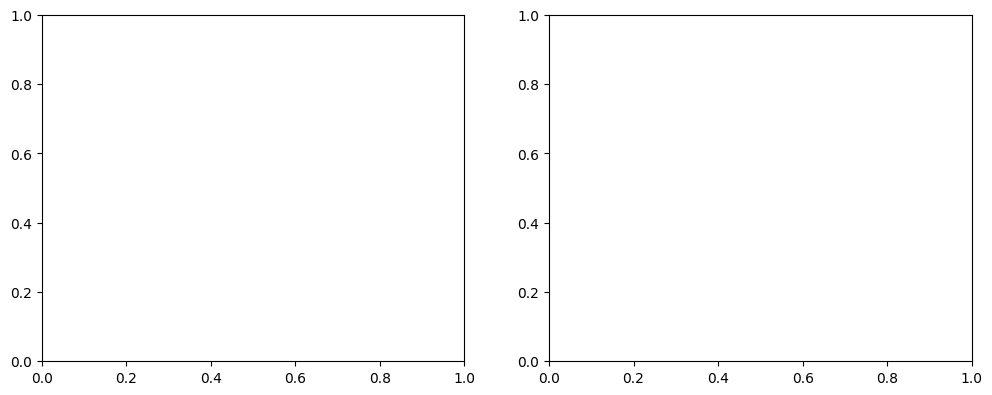

In [ ]:
# Gate evolution across epochs -- Fold 1 (LMO) vs mean across LSO subjects
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

gate_cols = [("val_beta", "β (Image)", "blue"), ("val_alpha", "α (EEG)", "red")]

if 1 in lmo_histories:
    hist1 = lmo_histories[1]
    for ax, (gcol, glabel, gcolor) in zip(axes, gate_cols):
        ax.plot(hist1["epoch"], hist1[gcol], color=gcolor, linewidth=2, marker="o", markersize=4)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.5, label="0.5 baseline")
        ax.set_title(f"Gate {glabel}\nLMO Fold 1 -- evolution over epochs", fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Mean gate value (0=ignore, 1=trust)")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
gate_plot_path = os.path.join(OUTPUT_DIR, "m1_gate_evolution.png")
plt.savefig(gate_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Plot saved in {gate_plot_path}")

## Results Summary

In [23]:
print(f"\n{'='*60}\nLEAVE-MEME-OUT (primary, {LMO_N_FOLDS} folds)\n{'='*60}")
for task, tname in [("21","Sexism Detection"), ("22","Source Intention"), ("23","Sexism Categorization")]:
    f1  = df_lmo_results[f"f1_{task}"]
    auc = df_lmo_results[f"auc_{task}"]
    print(f"  Task 2.{task[-1]} ({tname}): F1 = {f1.mean():.4f} ± {f1.std():.4f} | AUC = {auc.mean():.4f} ± {auc.std():.4f}")
print(f"  Gates: β(Image) = {df_lmo_results['beta_image'].mean():.4f} | α(EEG) = {df_lmo_results['alpha_eeg'].mean():.4f}")

print(f"\n{'='*60}\nLEAVE-SUBJECT-OUT (ablation, {len(WELL_REPRESENTED)} subjects)\n{'='*60}")
for task, tname in [("21","Sexism Detection"), ("22","Source Intention"), ("23","Sexism Categorization")]:
    f1 = df_lso_results[f"f1_{task}"]
    print(f"  Task 2.{task[-1]} ({tname}): F1 = {f1.mean():.4f} ± {f1.std():.4f}")

print(f"\n{'='*60}\nGAP (LMO - LSO)\n{'='*60}")
print(df_gap.to_string(index=False))


LEAVE-MEME-OUT (primary, 5 folds)
  Task 2.1 (Sexism Detection): F1 = 0.6335 ± 0.0082 | AUC = 0.6780 ± 0.0145
  Task 2.2 (Source Intention): F1 = 0.5387 ± 0.0353 | AUC = 0.5800 ± 0.0436
  Task 2.3 (Sexism Categorization): F1 = 0.1643 ± 0.0441 | AUC = 0.6380 ± 0.0305
  Gates: β(Image) = 0.8876 | α(EEG) = 0.0367

LEAVE-SUBJECT-OUT (ablation, 8 subjects)
  Task 2.1 (Sexism Detection): F1 = 0.6308 ± 0.0179
  Task 2.2 (Source Intention): F1 = 0.5200 ± 0.0287
  Task 2.3 (Sexism Categorization): F1 = 0.0695 ± 0.0376

GAP (LMO - LSO)
            task   lmo_f1   lso_f1      gap
    2.1 (Sexism) 0.633474 0.630846 0.002628
 2.2 (Intention) 0.538696 0.519950 0.018746
2.3 (Categories) 0.164341 0.069476 0.094865
